In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
iris = load_iris()
X = iris.data
y = iris.target



In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 rows of scaled X_train:")
print(X_train_scaled[:5])
print("\nFirst 5 rows of scaled X_test:")
print(X_test_scaled[:5])

First 5 rows of scaled X_train:
[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]

First 5 rows of scaled X_test:
[[ 0.35451684 -0.58505976  0.55777524  0.02224751]
 [-0.13307079  1.65083742 -1.16139502 -1.17911778]
 [ 2.30486738 -1.0322392   1.8185001   1.49058286]
 [ 0.23261993 -0.36147005  0.44316389  0.4227026 ]
 [ 1.2077952  -0.58505976  0.61508092  0.28921757]]


In [5]:
# Initialize the KNN model with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

print("KNN model initialized and trained with k=5.")

KNN model initialized and trained with k=5.


In [6]:
# Make predictions on the scaled test set
y_pred = knn.predict(X_test_scaled)

print("First 5 predictions:")
print(y_pred[:5])
print("\nFirst 5 actual labels:")
print(y_test[:5])

First 5 predictions:
[1 0 2 1 1]

First 5 actual labels:
[1 0 2 1 1]


In [7]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine features (X) and target (y) into a single DataFrame for easier EDA
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = y

print("First 5 rows of the Iris DataFrame:")
display(iris_df.head())

print("\nDataFrame Info:")
iris_df.info()

First 5 rows of the Iris DataFrame:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### Exploratory Data Analysis (EDA)

In [12]:
print("\nDescriptive Statistics:")
display(iris_df.describe())

print("\nMissing Values:")
print(iris_df.isnull().sum())


Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


#### Visualizing Feature Distributions

### Data Cleaning

The Iris dataset is known to be very clean and does not typically require extensive cleaning. However, in a real-world scenario, you might perform steps like:

*   **Handling Missing Values**: Imputing or removing rows/columns with NaNs.
*   **Removing Duplicates**: Identifying and dropping duplicate rows.
*   **Correcting Data Types**: Ensuring columns have appropriate data types.
*   **Outlier Detection and Treatment**: Identifying and handling anomalous data points.

In [14]:
# Example of checking for and dropping duplicates (though unlikely in Iris)
initial_rows = iris_df.shape[0]
iris_df.drop_duplicates(inplace=True)
dropped_rows = initial_rows - iris_df.shape[0]

if dropped_rows > 0:
    print(f"Dropped {dropped_rows} duplicate rows.")
else:
    print("No duplicate rows found.")

# For Iris, no further cleaning is typically needed as it's a pristine dataset.
print("\nData cleaning complete. The Iris dataset is already very clean.")

Dropped 1 duplicate rows.

Data cleaning complete. The Iris dataset is already very clean.


In [15]:
def remove_outliers_iqr(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

print(f"Shape of iris_df before outlier removal: {iris_df.shape}")

# Identify numerical columns for outlier removal (excluding 'species')
numerical_cols = iris_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'species' in numerical_cols:
    numerical_cols.remove('species')

iris_df_cleaned = remove_outliers_iqr(iris_df, numerical_cols)

print(f"Shape of iris_df after outlier removal: {iris_df_cleaned.shape}")

Shape of iris_df before outlier removal: (149, 5)
Shape of iris_df after outlier removal: (145, 5)


#### Visualizing Feature Distributions After Outlier Removal

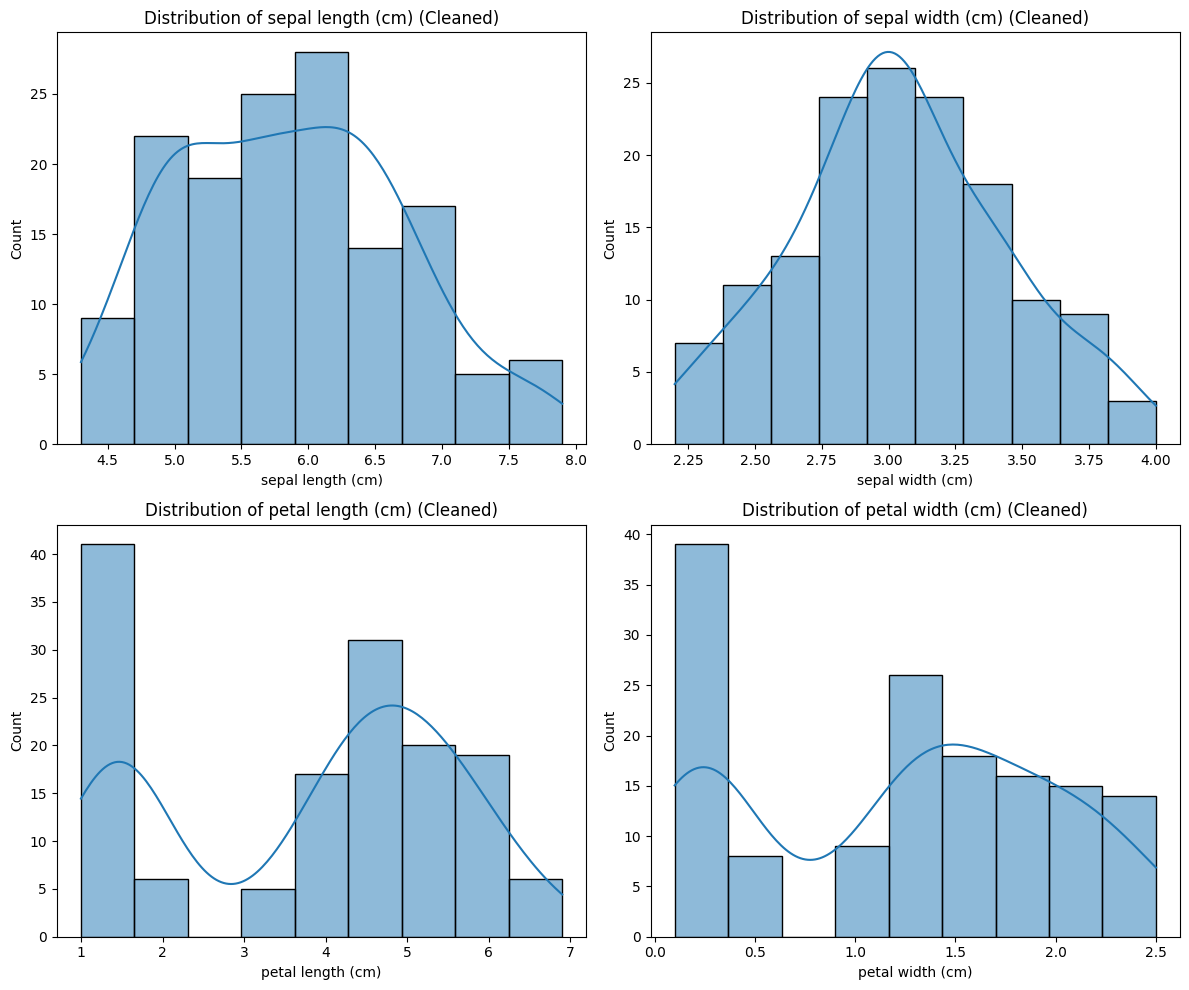


Descriptive Statistics after outlier removal:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,145.000000,145.000000,145.000000,145.000000,145.000000
mean,5.857241,3.042759,3.797931,1.215862,1.013793
std,0.836971,0.398216,1.760819,0.759905,0.816379
min,4.300000,2.200000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.400000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.000000,6.900000,2.500000,2.000000


In [16]:
plt.figure(figsize=(12, 10))
for i, feature in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns
    sns.histplot(iris_df_cleaned[feature], kde=True)
    plt.title(f'Distribution of {feature} (Cleaned)')
plt.tight_layout()
plt.show()

print("\nDescriptive Statistics after outlier removal:")
display(iris_df_cleaned.describe())

#### Univariate Analysis: Box Plots

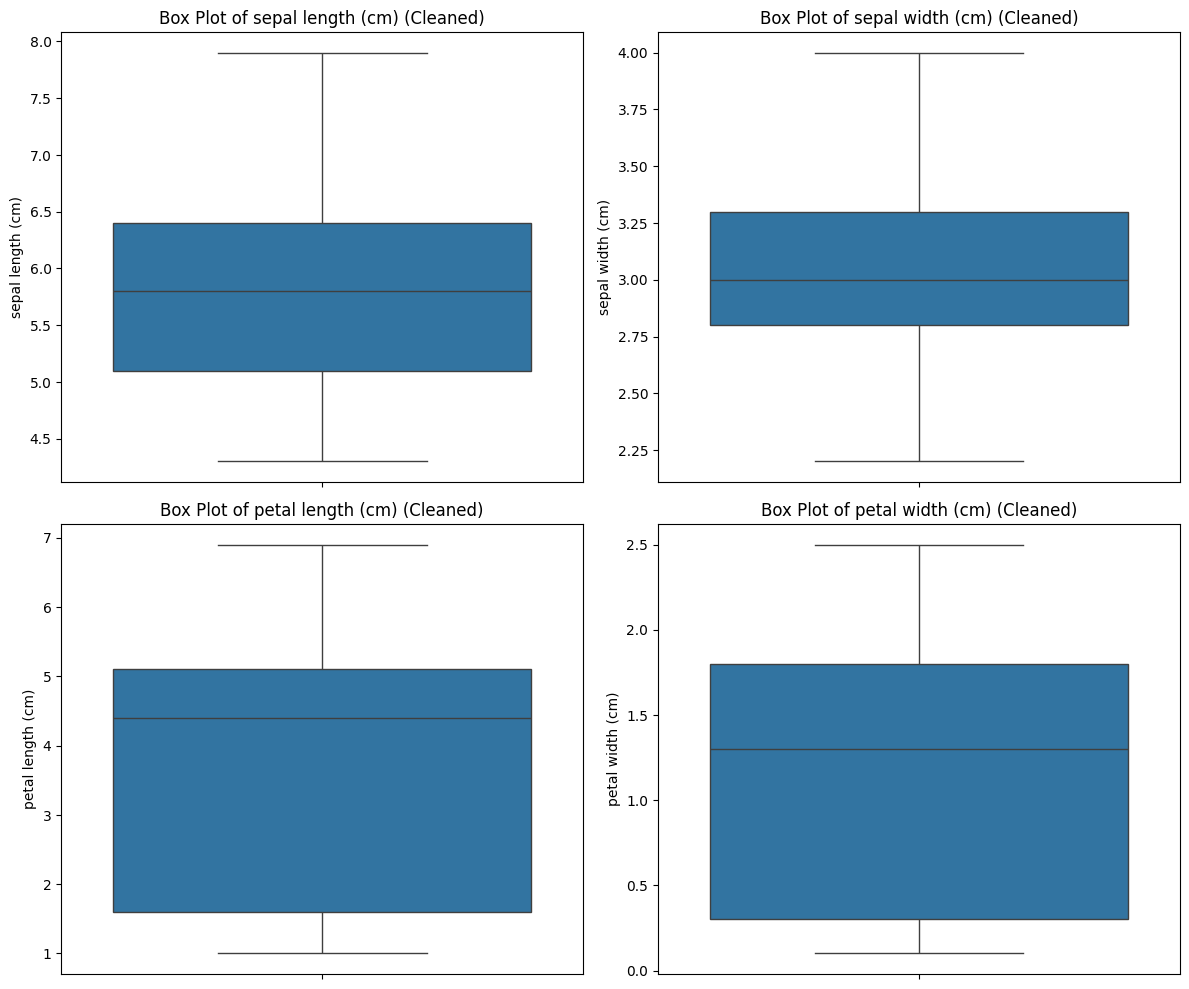

In [17]:
plt.figure(figsize=(12, 10))
for i, feature in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=iris_df_cleaned[feature])
    plt.title(f'Box Plot of {feature} (Cleaned)')
plt.tight_layout()
plt.show()

#### Bivariate Analysis: Scatter Plots and Violin Plots

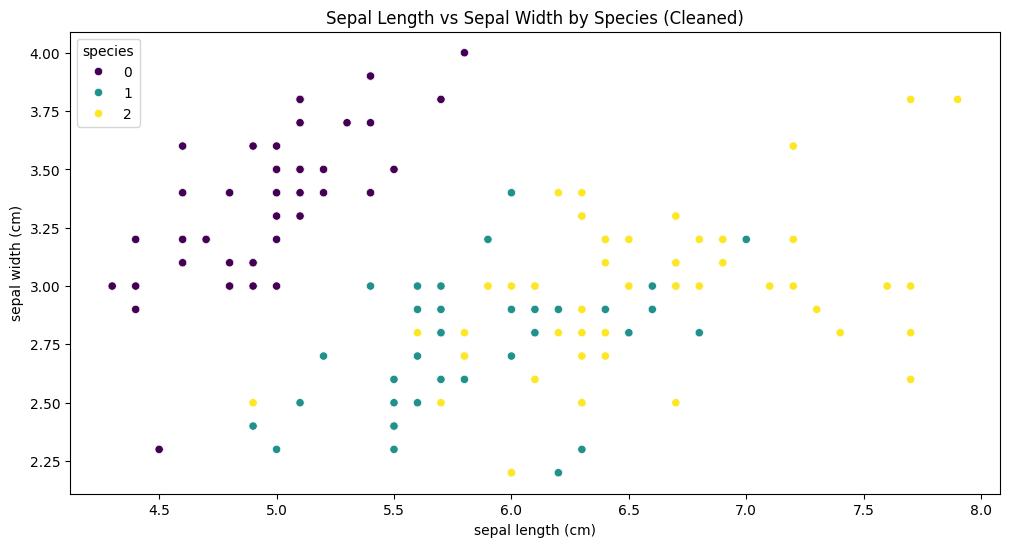

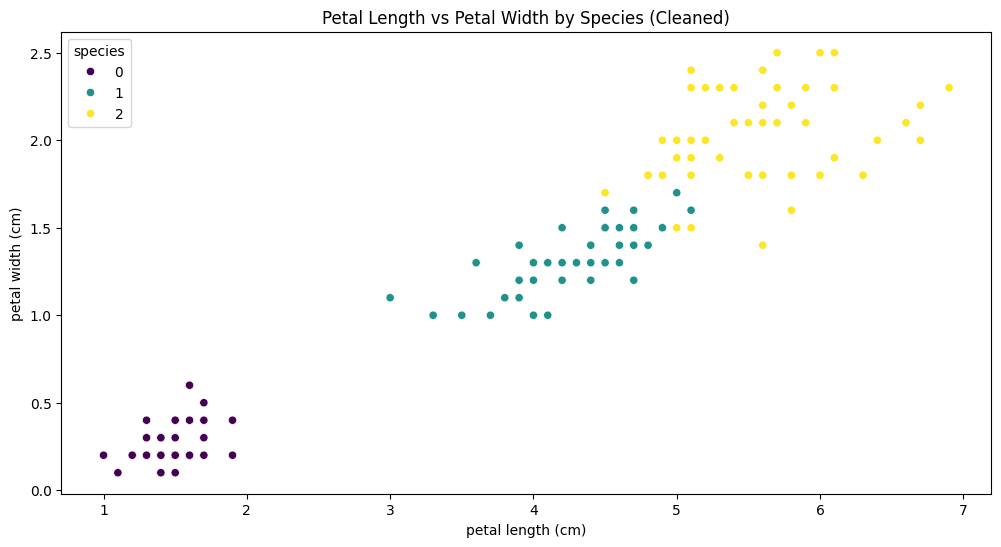

/tmp/ipykernel_1146/2917638801.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=iris_df_cleaned, x='species', y=feature, palette='muted')
/tmp/ipykernel_1146/2917638801.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=iris_df_cleaned, x='species', y=feature, palette='muted')
/tmp/ipykernel_1146/2917638801.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=iris_df_cleaned, x='species', y=feature, palette='muted')
/tmp/ipykernel_1146/2917638801.py:17: FutureWarning: 

Passing `palette` without assigning `hue` 

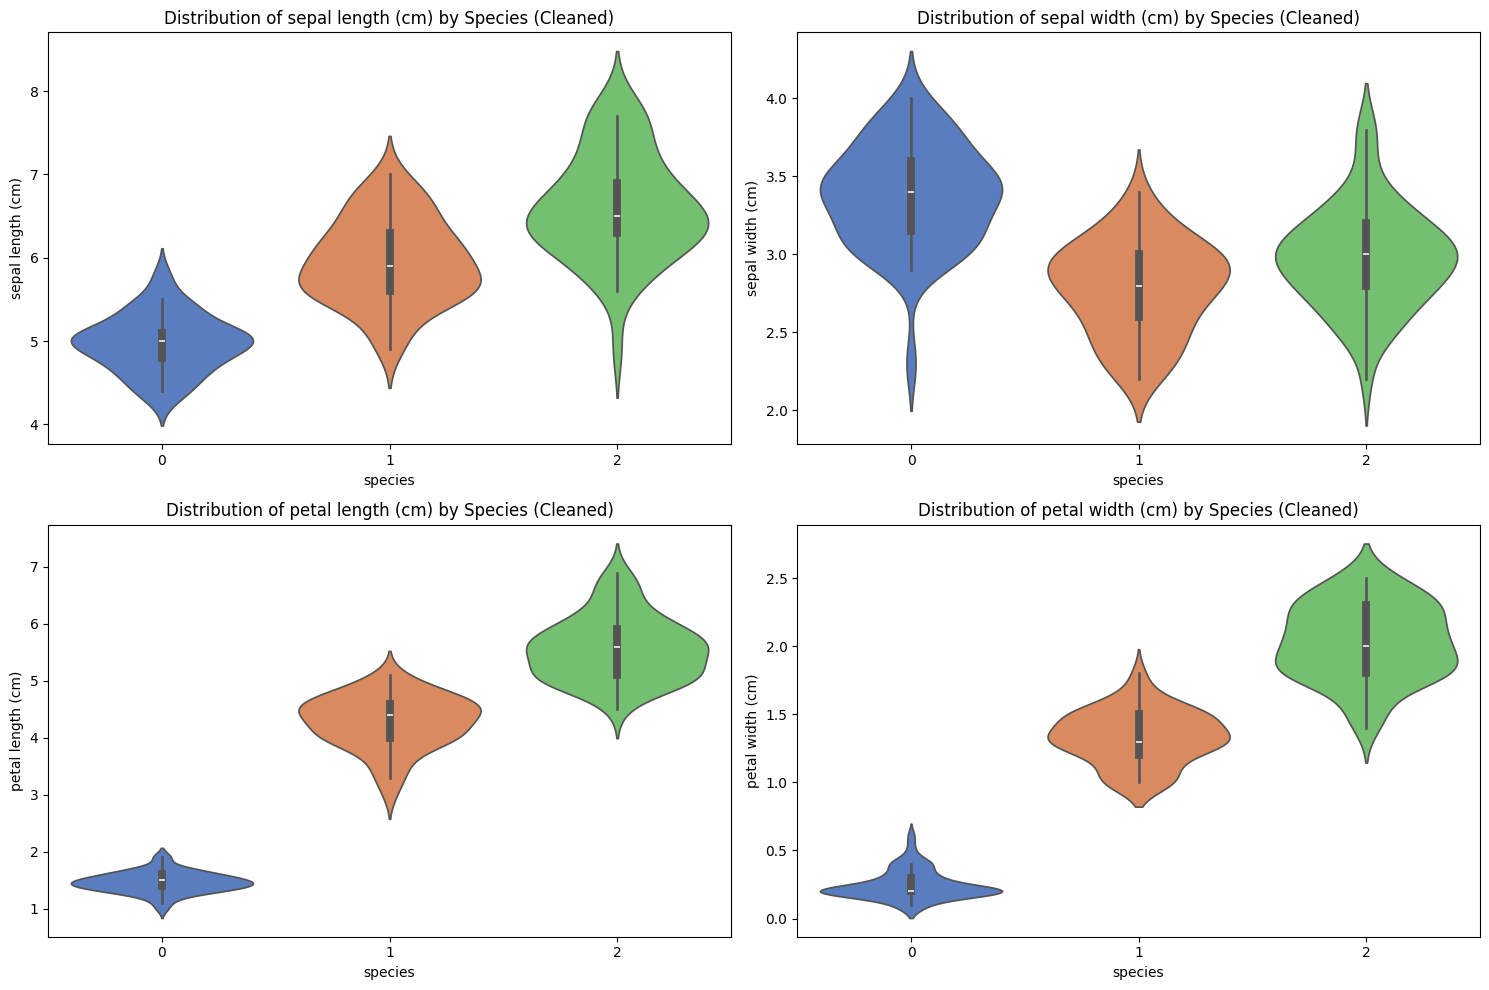

In [18]:
# Scatter plot for Sepal Length vs Sepal Width by Species
plt.figure(figsize=(12, 6))
sns.scatterplot(data=iris_df_cleaned, x='sepal length (cm)', y='sepal width (cm)', hue='species', palette='viridis')
plt.title('Sepal Length vs Sepal Width by Species (Cleaned)')
plt.show()

# Scatter plot for Petal Length vs Petal Width by Species
plt.figure(figsize=(12, 6))
sns.scatterplot(data=iris_df_cleaned, x='petal length (cm)', y='petal width (cm)', hue='species', palette='viridis')
plt.title('Petal Length vs Petal Width by Species (Cleaned)')
plt.show()

# Violin plots for feature distribution across species
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(data=iris_df_cleaned, x='species', y=feature, palette='muted')
    plt.title(f'Distribution of {feature} by Species (Cleaned)')
plt.tight_layout()
plt.show()

#### Multivariate Analysis: Correlation Heatmap

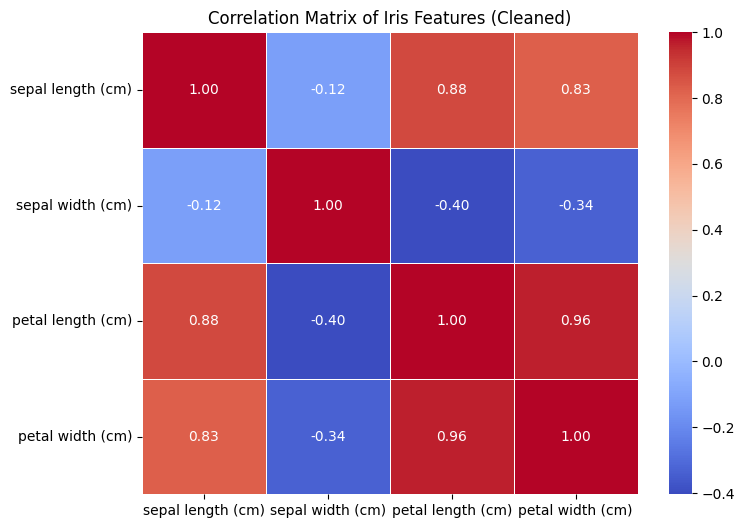

In [19]:
# Calculate the correlation matrix
correlation_matrix = iris_df_cleaned[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Iris Features (Cleaned)')
plt.show()